# Loading Libraries and Packages

In [1]:
import copy, math, os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler

# Setting the random seed for reproducibility
np.random.seed(42)

import warnings
warnings.filterwarnings("ignore")

if torch.backends.mps.is_available():
    print(f"MPS available. \nUsing MPS as runtime.")
    device = torch.device("mps")
    
elif torch.cuda.is_available():
    print(f"CUDA available. \nUsing CUDA as runtime.")
    device = torch.device("cuda")

else:
    print(f"No GPU available. \nUsing CPU runtime.")
    device = torch.device('cpu')

MPS available. 
Using MPS as runtime.


# 3.7 Vanilla RNN from Scratch

## Loading and Flattening Dataset 

In [2]:
def flatten_data(X,y, window = 72, time_ahead = 24):
    
    X_flat = []
    y_flat = []
    curr_index =  window  # We do not include current time step. 
    while (curr_index+time_ahead) < X.shape[0]:
        X_flat.append(X[curr_index-window:curr_index])
        y_flat.append(y[curr_index + time_ahead].flatten())
        curr_index += 1
        
    X_flat = np.array(X_flat)
    y_flat = np.array(y_flat)
    
    return (X_flat, y_flat)

In [3]:
def flatten_data(X, y, window=72, time_ahead=24):

    X_flat, y_flat = [], []
    curr_index = window

    while (curr_index + time_ahead) < X.shape[0]:
        X_flat.append(X[curr_index-window:curr_index])
        y_flat.append(y[curr_index + time_ahead])  # no flatten()
        curr_index += 1

    return np.array(X_flat), np.array(y_flat)

In [4]:
def get_phase3_data(input_columns, target_columns, time_steps = 24, sliding_window = 72, preprocess = True):
    # Creating Dataframe
    data_path = "../delhi_aqi.csv" 
    df = pd.read_csv(data_path)
    
    # Input Data
    X = np.array(df[input_columns].copy())
    y = np.array(df[[target_columns]].copy())
    
    # Train-Validation-Split Split (70-15-15)
    train_pct = 0.7
    val_pct = 0.15
    test_pct = 0.15
    
    
    train_index = int(X.shape[0]*train_pct)
    val_index = train_index + int(math.ceil(X.shape[0]*val_pct))
    
    X_train = X[:train_index].copy() # Training Data
    X_val = X[train_index:val_index].copy() # Validation Data
    X_test = X[val_index:].copy() # Test Data

    y_train = y[:train_index].copy() # Training Data
    y_val = y[train_index:val_index].copy() # Validation Data
    y_test = y[val_index:].copy() # Test Data

    std_scaler = StandardScaler()
    std_scaler_target = StandardScaler()

    # Pre-processing Data
    if preprocess:
        print("Standard Scaler applied on Data.")
        # --- Correct scaling ---
        X_train = std_scaler.fit_transform(X_train)
        X_val   = std_scaler.transform(X_val)
        X_test  = std_scaler.transform(X_test)
        
        y_train = std_scaler_target.fit_transform(y_train) 
        y_val   = std_scaler_target.transform(y_val)
        y_test  = std_scaler_target.transform(y_test)

    print()
    print("Input Data Shape:", X.shape)
    print("Input Target Shape:", y.shape)
    
    print()
    print("#"*10, "Dimensions of Original Dataset","#"*10)
    print()
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    print()
    print("#"*10, "Dimensions After Flattening","#"*10)
    print()
    X_train, y_train = flatten_data(X_train,y_train, time_ahead = time_steps, window = sliding_window)
    X_val, y_val = flatten_data(X_val,y_val, time_ahead = time_steps, window = sliding_window)
    X_test, y_test = flatten_data(X_test, y_test, time_ahead = time_steps, window = sliding_window)
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    
    
    return {
        'train': (X_train, y_train),
        'val': (X_val, y_val),
        'test': (X_test, y_test),
        'std_scalers': (std_scaler, std_scaler_target)
    }

## Vanilla RNN Class

In [5]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.input_dim = input_size
        self.hidden_dim = hidden_size
        self.output_dim = output_size

        # Single linear layer for [x_t, h_{t-1}]
        self.rnn_cell = nn.Linear(input_size + hidden_size, hidden_size)
        self.activation = nn.Tanh()

        # Output layer
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        """
        X shape: (batch_size, seq_len, input_size)
        """

        batch_size, seq_len, _ = X.shape
        device = X.device

        # Initialize hidden state
        h = torch.zeros(batch_size, self.hidden_dim, device=device)

        # Loop over time steps
        for t in range(seq_len):
            x_t = X[:, t, :]  # (batch_size, input_dim)

            # Concatenate input and hidden state
            combined = torch.cat((x_t, h), dim=1)

            # RNN cell computation
            h = self.activation(self.rnn_cell(combined))

        # Final output (many-to-one)
        out = self.output_layer(h)

        return out

## Training Loop

In [6]:
def train_full_batch(
    model,
    X_train, y_train,
    X_val, y_val,
    save_path,
    epochs=100,
    lr=1e-3,
    patience=20,   # NEW: early stopping patience
    verbose=True
):
    # --- Loss & Optimizer ---
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # --- Device ---
    device = next(model.parameters()).device
    X_train, y_train = X_train.to(device), y_train.to(device)
    X_val, y_val = X_val.to(device), y_val.to(device)

    # --- Shape fix ---
    if len(y_train.shape) == 2:
        y_train = y_train.squeeze(1)
    if len(y_val.shape) == 2:
        y_val = y_val.squeeze(1)

    # --- Tracking ---
    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    train_losses = []
    val_losses = []
    best_epoch = None

    # --- Training loop ---
    for epoch in range(epochs):
        model.train()

        # --- Forward (FULL batch) ---
        preds_train = model(X_train).squeeze(1)
        train_loss = criterion(preds_train, y_train)

        # --- Backprop ---
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # --- Validation ---
        model.eval()
        with torch.no_grad():
            preds_val = model(X_val).squeeze(1)
            val_loss = criterion(preds_val, y_val)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        # --- Check improvement ---
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, save_path)
            best_epoch = epoch+1
            epochs_without_improvement = 0  # reset counter
        else:
            epochs_without_improvement += 1

        # --- Early stopping ---
        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

        # --- Logging ---
        if verbose:
            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"Train: {train_loss.item():.4f} | "
                f"Val: {val_loss.item():.4f} | "
                f"Best: {best_val_loss:.4f}"
            )

    # --- Load best model ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    print(f"Best Model found at epoch: {best_epoch}")

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss
    }

### Loading and Pre-processing Data

In [5]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase3_data = get_phase3_data(input_columns, target_columns, time_steps = 24, sliding_window = 100)
std_scaler_data, std_scaler_target = phase3_data['std_scalers']

Standard Scaler applied on Data.

Input Data Shape: (18776, 8)
Input Target Shape: (18776, 1)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143, 1)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817, 1)
Test Data Shape: (2816, 8)
Test Target Shape: (2816, 1)

########## Dimensions After Flattening ##########

Train Data Shape: (13019, 100, 8)
Train Target Shape: (13019, 1)
Validation Data Shape: (2693, 100, 8)
Validation Target Shape: (2693, 1)
Test Data Shape: (2692, 100, 8)
Test Target Shape: (2692, 1)


In [202]:
#####  1. Data Loading  #####
X_train, y_train = phase3_data['train']
X_val, y_val = phase3_data['val']
X_test, y_test = phase3_data['test']

#####  2. Model Saving Config.  #####
save_dir = "../Models"
model_num = 5
save_path = os.path.join(save_dir, f"3_7_{model_num}.pth")
lr = 5e-4

#####  3. Convert NumPy → Torch Tensor  #####
def to_tensor(x, dtype=torch.float32):
    return torch.from_numpy(x).to(dtype)


X_train = to_tensor(X_train).to(device)
y_train = to_tensor(y_train).to(device)

X_val = to_tensor(X_val).to(device)
y_val = to_tensor(y_val).to(device)

X_test = to_tensor(X_test).to(device)
y_test = to_tensor(y_test).to(device)


#####  4. Model Initialization  #####
input_size = X_train.shape[2]   # 8 features
hidden_size = 128
output_size = 1

model = VanillaRNN(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


#####  5. Train Model  #####
results = train_full_batch(
    model,
    X_train, y_train,
    X_val, y_val,
    save_path,
    epochs=100,
    lr=1e-3,
    patience=15,   # NEW: early stopping patience
    verbose=True)

Epoch [1/100] | Train: 0.9363 | Val: 0.3030 | Best: 0.3030
Epoch [2/100] | Train: 0.8601 | Val: 0.2887 | Best: 0.2887
Epoch [3/100] | Train: 0.8050 | Val: 0.2844 | Best: 0.2844
Epoch [4/100] | Train: 0.7674 | Val: 0.2888 | Best: 0.2844
Epoch [5/100] | Train: 0.7426 | Val: 0.2993 | Best: 0.2844
Epoch [6/100] | Train: 0.7257 | Val: 0.3135 | Best: 0.2844
Epoch [7/100] | Train: 0.7122 | Val: 0.3304 | Best: 0.2844
Epoch [8/100] | Train: 0.7003 | Val: 0.3495 | Best: 0.2844
Epoch [9/100] | Train: 0.6907 | Val: 0.3673 | Best: 0.2844
Epoch [10/100] | Train: 0.6839 | Val: 0.3762 | Best: 0.2844
Epoch [11/100] | Train: 0.6788 | Val: 0.3694 | Best: 0.2844
Epoch [12/100] | Train: 0.6723 | Val: 0.3471 | Best: 0.2844
Epoch [13/100] | Train: 0.6633 | Val: 0.3160 | Best: 0.2844
Epoch [14/100] | Train: 0.6537 | Val: 0.2862 | Best: 0.2844
Epoch [15/100] | Train: 0.6472 | Val: 0.2661 | Best: 0.2661
Epoch [16/100] | Train: 0.6460 | Val: 0.2553 | Best: 0.2553
Epoch [17/100] | Train: 0.6458 | Val: 0.2500 | Be

In [220]:
save_dir = "../Models"
model_num = 3
save_path = os.path.join(save_dir, f"3_7_{model_num}.pth")

# -------------------------------
# 5. Load Best Model (optional safety)
# -------------------------------
print("Loading Model from: ", save_path)
best_model = VanillaRNN(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size
).to(device)

best_model.load_state_dict(torch.load(save_path))
best_model.eval()

# -------------------------------
# 6. Test Evaluation
# -------------------------------
with torch.no_grad():

    train_pred = best_model(X_train)
    val_pred = best_model(X_val)
    test_pred =  best_model(X_test)
    
    train_mse = criterion(train_pred, y_train)
    train_rmse = torch.sqrt(train_mse)
    
    val_mse = criterion(val_pred, y_val)
    val_rmse = torch.sqrt(val_mse)
    
    test_mse = criterion(test_pred, y_test)
    test_rmse = torch.sqrt(test_mse)


print("\nTrain Stats")
print(f"Train MSE  : {train_mse.item():.4f}")
print(f"Train RMSE : {train_rmse.item():.4f}")

print("\nValidation Stats")
print(f"Val MSE  : {val_mse.item():.4f}")
print(f"Val RMSE : {val_rmse.item():.4f}")

print("\nTest Stats")
print(f"Test MSE  : {test_mse.item():.4f}")
print(f"Test RMSE : {test_rmse.item():.4f}")

Loading Model from:  ../Models/3_7_3.pth

Train Stats
Train MSE  : 0.5941
Train RMSE : 0.7708

Validation Stats
Val MSE  : 0.2176
Val RMSE : 0.4665

Test Stats
Test MSE  : 0.7474
Test RMSE : 0.8645


# 3.8 BPTT Decay

In [7]:
def run_bptt_decay_experiment(model, seq_len=100, input_dim=8, X = None, y = None):
    model.eval()

    device = next(model.parameters()).device

    # --- Dummy input ---
    X = torch.randn(1, seq_len, input_dim, device=device)

    # --- Initialize hidden state ---
    h = torch.zeros(1, model.hidden_dim, device=device)

    hidden_states = []

    # --- Forward pass ---
    for t in range(seq_len):
        x_t = X[:, t, :]

        combined = torch.cat((x_t, h), dim=1)
        h = model.activation(model.rnn_cell(combined))

        # IMPORTANT: retain gradient for intermediate states
        h.retain_grad()
        hidden_states.append(h)

    # --- Final output ---
    out = model.output_layer(h)

    # Dummy target
    target = torch.randn_like(out)

    # Loss
    criterion = nn.MSELoss()
    loss = criterion(out, target)

    # --- Backward pass (ONLY ONCE) ---
    loss.backward()

    # --- Extract gradient norms ---
    grad_norms = []
    for h_t in hidden_states:
        grad_norms.append(h_t.grad.norm().item())

    return grad_norms

## Driver Code

In [8]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase3_data = get_phase3_data(input_columns, target_columns, time_steps = 24, sliding_window = 100)
std_scaler_data, std_scaler_target = phase3_data['std_scalers']

X_train, y_train = phase3_data['train']
X_val, y_val = phase3_data['val']
X_test, y_test = phase3_data['test']

X_train = torch.tensor(X_train, dtype = torch.float32).to(device)
X_val = torch.tensor(X_val, dtype = torch.float32).to(device)
X_test = torch.tensor(X_test, dtype = torch.float32).to(device)

y_train = torch.tensor(y_train, dtype = torch.float32).to(device)
y_val =  torch.tensor(y_val, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.float32).to(device)

Standard Scaler applied on Data.

Input Data Shape: (18776, 8)
Input Target Shape: (18776, 1)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143, 1)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817, 1)
Test Data Shape: (2816, 8)
Test Target Shape: (2816, 1)

########## Dimensions After Flattening ##########

Train Data Shape: (13019, 100, 8)
Train Target Shape: (13019, 1)
Validation Data Shape: (2693, 100, 8)
Validation Target Shape: (2693, 1)
Test Data Shape: (2692, 100, 8)
Test Target Shape: (2692, 1)


In [10]:
model = VanillaRNN(input_size=8, hidden_size=64, output_size=1)
model = model.to(device)

grad_norms = run_bptt_decay_experiment(model, X = X_train , seq_len=100, input_dim=8)

print("Gradient norms:")

print(f"t = 100: {grad_norms[99]}")
print(f"t = 50 : {grad_norms[49]}")
print(f"t = 1  : {grad_norms[0]}")

Gradient norms:
t = 100: 0.1657068431377411
t = 50 : 5.403315920642906e-15
t = 1  : 0.0


## Visualization

In [25]:
def plot_gradient_decay(grad_norms, save_path=None, values_path=None):
    timesteps = list(range(1, len(grad_norms) + 1))

    # --- Save gradient values ---
    if values_path is not None:
        np.save(values_path, np.array(grad_norms))   # saves as .npy file

    plt.figure(figsize=(10, 6))

    plt.plot(
        timesteps,
        grad_norms,
        linewidth=2
    )

    plt.xlabel("Time Step", fontsize=12)
    plt.ylabel(r"Gradient Norm $\|\partial L / \partial h_t\|$", fontsize=12)
    plt.title("Gradient Flow Comparison: Vanilla RNN vs LSTM", fontsize=14)

    # --- LOG SCALE ---
    plt.yscale('log')

    # Grid
    plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

    # Highlight key points
    # key_steps = [1, 50, 100]
    key_steps = [ 50, 100]
    # key_vals = [grad_norms[0], grad_norms[49], grad_norms[99]]
    key_vals = [grad_norms[49], grad_norms[99]]


    plt.scatter(key_steps, key_vals, zorder=3)

    # Annotate
    for t, val in zip(key_steps, key_vals):
        plt.text(t, val, f"{val:.2e}", fontsize=9, va='bottom')

    plt.tight_layout()

    # --- Save plot ---
    if save_path:
        plt.savefig(save_path, dpi=300)   # FIXED typo

    plt.show()

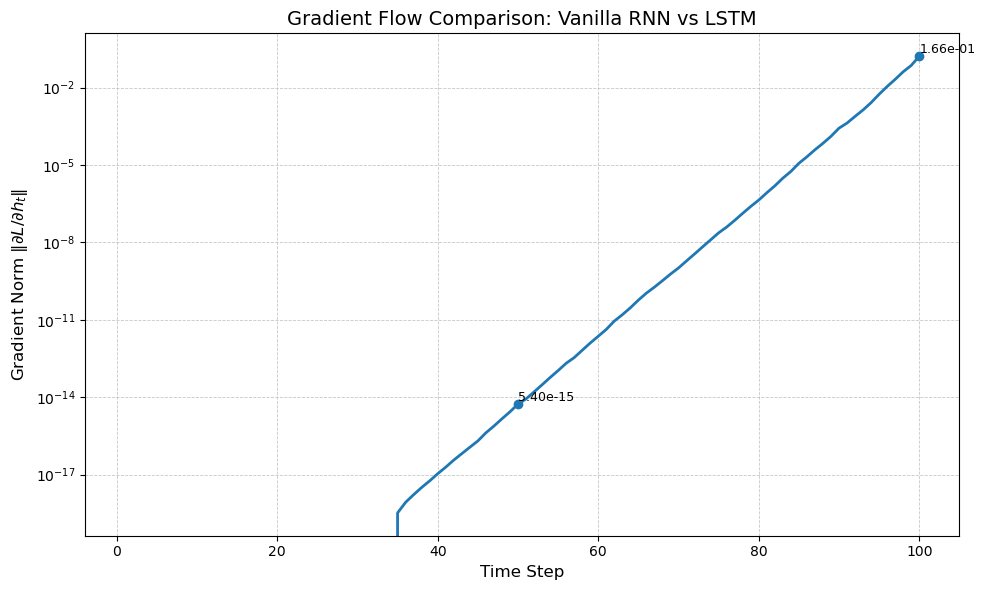

In [26]:
plot_gradient_decay(
    grad_norms,
    save_path="../Report/3_8_bptt_decay_rnn.png",
    values_path="../Report/gradients_rnn.npy"
)

# 3.9 Exploding Gradients

## Singular Value Calculation

In [145]:
def compute_max_singular_value(model):
    with torch.no_grad():
        W = model.rnn_cell.weight.data  # (hidden, input+hidden)
        hidden_dim = model.hidden_dim

        # Extract recurrent part
        W_h = W[:, -hidden_dim:]

        # SVD
        U, S, V = torch.svd(W_h)
        sigma_max = S.max().item()

    return sigma_max

## Training Loop

In [163]:
def train_exploding_rnn(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    lr=0.05,   # HIGH LR to induce explosion
    verbose=True
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    device = next(model.parameters()).device
    X_train, y_train = X_train.to(device), y_train.to(device)
    X_val, y_val = X_val.to(device), y_val.to(device)

    if len(y_train.shape) == 2:
        y_train = y_train.squeeze(1)
    if len(y_val.shape) == 2:
        y_val = y_val.squeeze(1)

    prev_state = None
    exploded = False
    explosion_epoch = None

    for epoch in range(epochs):
        model.train()

        # --- Save state BEFORE update ---
        prev_state = copy.deepcopy(model.state_dict())

        # --- Forward ---
        preds = model(X_train).squeeze(1)
        loss = criterion(preds, y_train)

        # --- Detect explosion BEFORE backward ---
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Loss exploded (NaN/Inf) at epoch {epoch+1}")
            exploded = True
            explosion_epoch = epoch + 1
            break

        # --- Backward ---
        optimizer.zero_grad()
        loss.backward()

        # OPTIONAL: print gradient norm (debug)
        total_grad_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total_grad_norm += p.grad.norm().item()

        optimizer.step()

        # --- Validation (optional monitoring) ---
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val).squeeze(1), y_val)

        if verbose:
            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"Train: {loss.item():.4f} | "
                f"Val: {val_loss.item():.4f} | "
                f"GradNorm: {total_grad_norm:.4f}"
            )

    # --- Restore last stable weights ---
    if exploded and prev_state is not None:
        model.load_state_dict(prev_state)

    return {
        "model": model,
        "exploded": exploded,
        "explosion_epoch": explosion_epoch
    }

## Driver Code

In [177]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase3_data = get_phase3_data(input_columns, target_columns, time_steps = 1, sliding_window = 72 ,std_scaler =  True)

Standard Scaler applied on Data.

Input Data Shape: (18776, 8)
Input Target Shape: (18776, 1)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143, 1)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817, 1)
Test Data Shape: (2816, 8)
Test Target Shape: (2816, 1)

########## Dimensions After Flattening ##########

Train Data Shape: (13070, 72, 8)
Train Target Shape: (13070, 1)
Validation Data Shape: (2744, 72, 8)
Validation Target Shape: (2744, 1)
Test Data Shape: (2743, 72, 8)
Test Target Shape: (2743, 1)


In [182]:
#####  1. Data Loading  #####
X_train, y_train = phase3_data['train']
X_val, y_val = phase3_data['val']
X_test, y_test = phase3_data['test']

#####  2. Convert NumPy → Torch Tensor  #####
def to_tensor(x, dtype=torch.float32):
    return torch.from_numpy(x).to(dtype)


X_train = to_tensor(X_train).to(device)
y_train = to_tensor(y_train).to(device)

X_val = to_tensor(X_val).to(device)
y_val = to_tensor(y_val).to(device)

X_test = to_tensor(X_test).to(device)
y_test = to_tensor(y_test).to(device)

# --- Initialize model ---
model = VanillaRNN(
    input_size=X_train.shape[2],
    hidden_size=64,
    output_size=1
).to(device)

# --- Train with high LR ---
results = train_exploding_rnn(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=200,
    lr= 0.5,   # increase further if needed (0.1, 0.5)
    verbose=True
)

# --- Check explosion ---
if results["exploded"]:
    print(f"\nExplosion detected at epoch {results['explosion_epoch']}")
else:
    print("\nNo explosion detected — increase LR further")

# --- Compute spectral norm ---
sigma_max = compute_max_singular_value(model)

print(f"\nMaximum Singular Value of W_h: {sigma_max:.4f}")

Epoch [1/200] | Train: 1.0733 | Val: 3.5876 | GradNorm: 5.1495
Epoch [2/200] | Train: 3.7462 | Val: 10.1364 | GradNorm: 30.0765
Epoch [3/200] | Train: 12.4079 | Val: 273.9116 | GradNorm: 498.6612
Epoch [4/200] | Train: 231.5959 | Val: 596602.2500 | GradNorm: 283.9343
Epoch [5/200] | Train: 591774.9375 | Val: 1419309568.0000 | GradNorm: 20325.8738
Epoch [6/200] | Train: 1432676864.0000 | Val: 2973186129920.0000 | GradNorm: 3693652.8945
Epoch [7/200] | Train: 2990800371712.0000 | Val: 10354049459159040.0000 | GradNorm: 442408062.2500
Epoch [8/200] | Train: 10225953133297664.0000 | Val: 40421842951184842752.0000 | GradNorm: 1689090680.0000
Epoch [9/200] | Train: 39861989222507347968.0000 | Val: 157580122299362218868736.0000 | GradNorm: 105461619712.0000
Epoch [10/200] | Train: 155399929719752161755136.0000 | Val: 614317640106836146274697216.0000 | GradNorm: 6584764268544.0000
Epoch [11/200] | Train: 605818228987898175529418752.0000 | Val: 2394886431012676498123692965888.0000 | GradNorm: 4